## Grafici test LoRa da csv su seriale

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import plotly.express as px
import math
import os

In [2]:
# --- Configurazione ---
FILE_PATH = r'C:\Users\leona\Desktop\LEO\UNI\TRIENNALE\TIROCINIO_RAILEVO\File_configurazione_ESP32-LoRa\869.525_MHz\file csv - antenna PCB\869.525 MHz SF12 125kHz 10%duty cycle 22dBm\dati_antenna.csv' 
OUTPUT_FOLDER = r'C:\Users\leona\Desktop\LEO\UNI\TRIENNALE\TIROCINIO_RAILEVO\File_configurazione_ESP32-LoRa\869.525_MHz\file csv - antenna PCB\869.525 MHz SF12 125kHz 10%duty cycle 22dBm\grafici da seriale'
LAT_RX = 45.225884
LON_RX = 11.231713

def haversine(lat1, lon1, lat2, lon2):
    R = 6371000 
    phi1, phi2 = np.radians(lat1), np.radians(lat2)
    dphi = np.radians(lat2 - lat1)
    dlambda = np.radians(lon2 - lon1)
    a = np.sin(dphi/2)**2 + np.cos(phi1) * np.cos(phi2) * np.sin(dlambda/2)**2
    return 2 * R * np.arcsin(np.sqrt(a))

# --- Caricamento e Ridenominazione ---
try:
    data = pd.read_csv(FILE_PATH)
    
    # Mappiamo i tuoi nomi reali verso quelli usati dagli script
    # Per dati seriale
    mapping = {
        'NodeID': 'id_tx',
        'PacketID': 'id_packet',
        'Lat': 'lat',
        'Lon': 'lon',
        'RSSI': 'rssi',
        'SNR': 'snr'
    }

    # Per dati TS
    # mapping = {
    #     'field1': 'id_tx',
    #     'field2': 'id_packet',
    #     'field3': 'lat',
    #     'field4': 'lon',
    #     'field5': 'rssi',
    #     'field6': 'snr'
    # }
    
    data = data.rename(columns=mapping)
    
    # Calcoliamo la distanza per ogni riga
    data['dist'] = data.apply(lambda row: haversine(row['lat'], row['lon'], LAT_RX, LON_RX), axis=1)
    
    print(f"Dati caricati con successo: {len(data)} pacchetti processati.")
    print(data.head()) # Verifica i primi 5 pacchetti
except Exception as e:
    print(f"Errore: {e}")

Dati caricati con successo: 44 pacchetti processati.
             Timestamp  id_tx  id_packet        lat        lon  rssi  snr  \
0  2026-06-04 12:00:03    101          0  45.225933  11.231882 -73.0  4.5   
1  2026-06-04 12:00:15    101          1  45.225918  11.231910 -74.0  4.8   
2  2026-06-04 12:00:27    101          2  45.225918  11.231909 -73.0  4.8   
3  2026-06-04 12:00:38    101          3  45.225910  11.231893 -73.0  5.0   
4  2026-06-04 12:00:50    101          4  45.225899  11.231888 -74.0  4.8   

        dist  
0  14.313033  
1  15.884727  
2  15.808672  
3  14.390299  
4  13.806435  


RSSI & SNR vs distanza

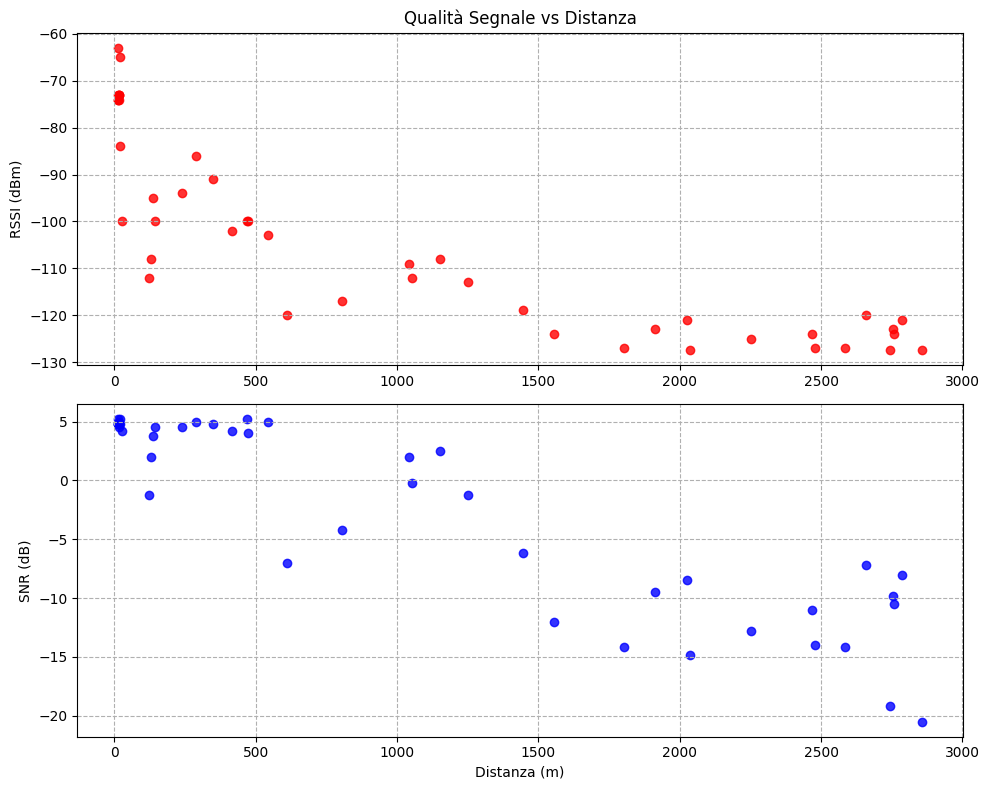

In [3]:
# Filtriamo i dati assurdi (ID 65535 e distanze eccessive)


df_plot = data[(data['id_packet'] < 60000) & (data['dist'] < 50000)].copy()

plt.figure(figsize=(10, 8))
plt.subplot(2, 1, 1)
plt.scatter(df_plot['dist'], df_plot['rssi'], color='red', alpha=0.8)
plt.grid(True, linestyle='--')
plt.ylabel('RSSI (dBm)')
plt.title('Qualità Segnale vs Distanza')

plt.subplot(2, 1, 2)
plt.scatter(df_plot['dist'], df_plot['snr'], color='blue', alpha=0.8)
plt.grid(True, linestyle='--')
plt.xlabel('Distanza (m)')
plt.ylabel('SNR (dB)')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_FOLDER, '1_qualita_distanza.png'), dpi=300)
plt.show()

Packet loss 

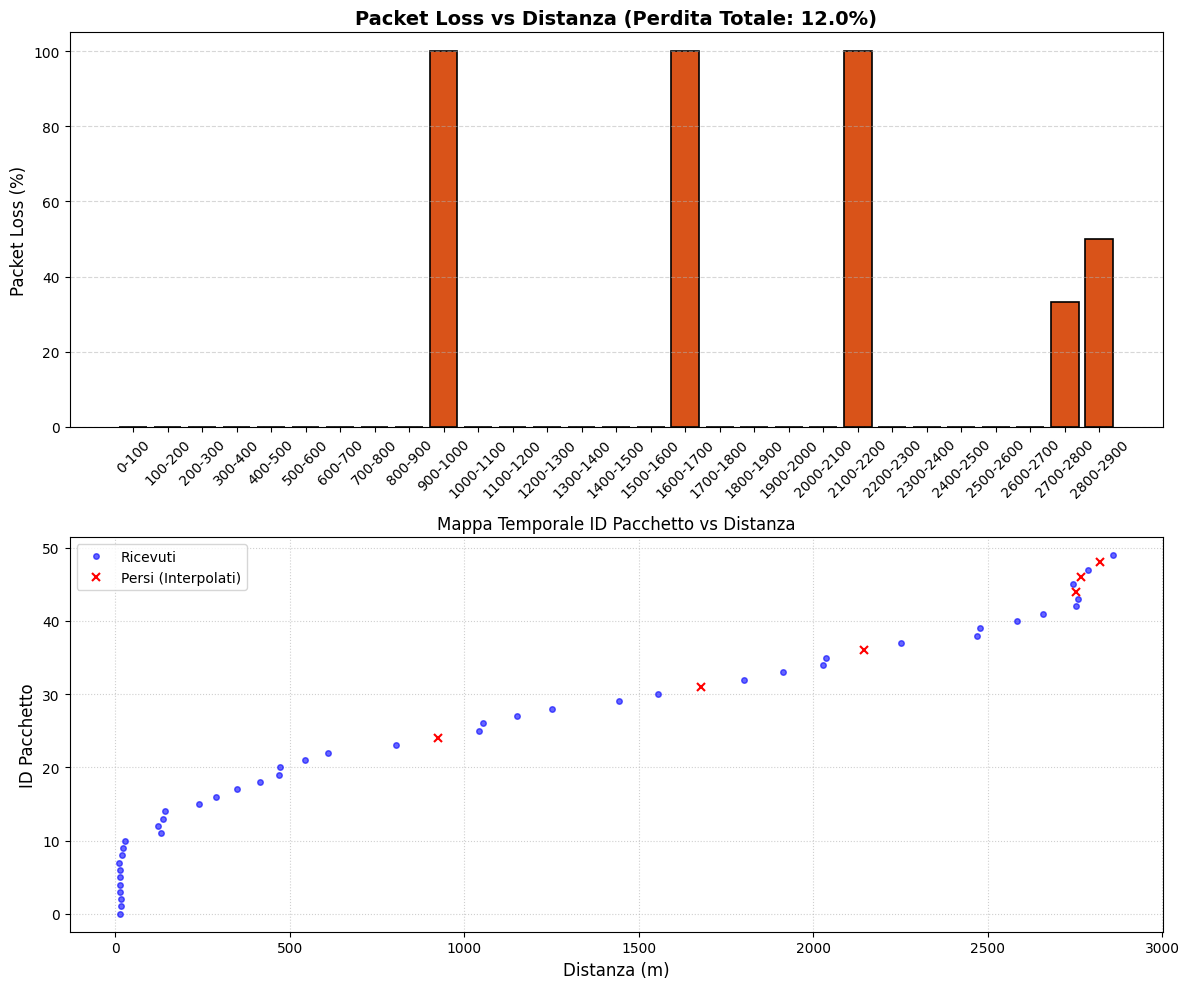

In [4]:
# --- 1. FILTRO E ORDINAMENTO ---
df_reliability = data[data['id_packet'] < 10000].sort_values('id_packet').drop_duplicates('id_packet').copy()

if not df_reliability.empty:
    # --- 2. RICOSTRUZIONE SEQUENZA IDEALE ---
    id_min, id_max = int(df_reliability['id_packet'].min()), int(df_reliability['id_packet'].max())
    all_ids = np.arange(id_min, id_max + 1)
    full_df = pd.DataFrame({'id_packet': all_ids})
    full_df = full_df.merge(df_reliability, on='id_packet', how='left')

    # Interpolazione lineare per assegnare distanza ai pacchetti persi
    full_df['dist'] = full_df['dist'].interpolate(method='linear').ffill().bfill()
    full_df['perso'] = full_df['rssi'].isna()
    
    # Identifichiamo i dati per lo scatter plot (ricevuti vs persi)
    id_persi = full_df[full_df['perso'] == True]
    id_ricevuti = full_df[full_df['perso'] == False]

    # --- 3. CONFIGURAZIONE BIN 100m PER ISTOGRAMMA ---
    passo_bin = 100 
    max_d = math.ceil(full_df['dist'].max() / passo_bin) * passo_bin
    if max_d == 0: max_d = passo_bin
    bins = np.arange(0, max_d + passo_bin, passo_bin)
    full_df['bin'] = pd.cut(full_df['dist'], bins=bins, right=False)

    bin_analysis = full_df.groupby('bin', observed=False).apply(
        lambda x: (x['perso'].sum() / len(x)) * 100 if len(x) > 0 else 0
    )
    labels_bin = [f"{int(b.left)}-{int(b.right)}" for b in bin_analysis.index]
    loss_totale = (full_df['perso'].sum() / len(full_df)) * 100

    # --- 4. CREAZIONE FIGURA DOPPIA (Subplots) ---
    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10))

    # GRAFICO SOPRA: Istogramma Loss (%)
    ax1.bar(labels_bin, bin_analysis.values, color='#D95319', edgecolor='black', linewidth=1.2)
    ax1.set_title(f"Packet Loss vs Distanza (Perdita Totale: {loss_totale:.1f}%)", fontsize=14, fontweight='bold')
    ax1.set_ylabel("Packet Loss (%)", fontsize=12)
    ax1.set_ylim(0, 105)
    ax1.grid(axis='y', linestyle='--', alpha=0.5)
    ax1.tick_params(axis='x', rotation=45)

    # GRAFICO SOTTO: Sequenza ID (Ricevuti vs Persi)
    # Ricevuti: cerchi blu
    ax2.plot(id_ricevuti['dist'], id_ricevuti['id_packet'], 'bo', label='Ricevuti', markersize=4, alpha=0.6)
    # Persi: croci rosse (sulla distanza interpolata)
    if not id_persi.empty:
        ax2.plot(id_persi['dist'], id_persi['id_packet'], 'rx', label='Persi (Interpolati)', markersize=6, markeredgewidth=1.5)
    
    ax2.set_title("Mappa Temporale ID Pacchetto vs Distanza", fontsize=12)
    ax2.set_xlabel("Distanza (m)", fontsize=12)
    ax2.set_ylabel("ID Pacchetto", fontsize=12)
    ax2.grid(True, linestyle=':', alpha=0.6)
    ax2.legend(loc='best')

    plt.tight_layout()
    plt.savefig(os.path.join(OUTPUT_FOLDER, '2_packet_loss.png'), dpi=300)
    plt.show()
else:
    print("Dati insufficienti per generare il grafico.")

SNR vs RSSI

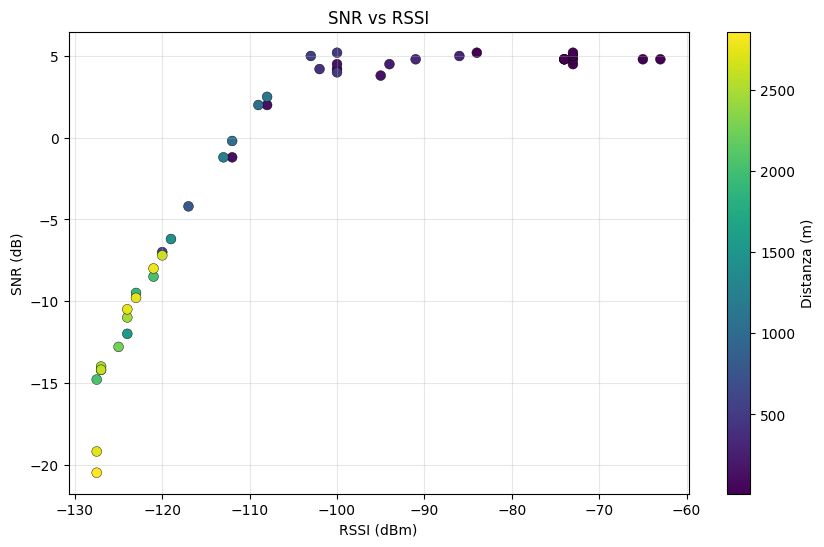

In [5]:
df_phys = data[data['id_packet'] < 60000].copy()

plt.figure(figsize=(10, 6))
# 'edgecolors' e 'linewidth' aiutano a definire meglio i punti
sc = plt.scatter(df_phys['rssi'], df_phys['snr'], c=df_phys['dist'], 
                    cmap='viridis', s=50, alpha=1.0, edgecolors='black', linewidth=0.3)
cb = plt.colorbar(sc)
cb.set_label('Distanza (m)')

#plt.axhline(-20, color='red', linestyle='--', label='Limite SF7')
plt.xlabel('RSSI (dBm)')
plt.ylabel('SNR (dB)')
plt.title('SNR vs RSSI')
plt.grid(True, alpha=0.3)
plt.savefig(os.path.join(OUTPUT_FOLDER, '3_snr_vs_rssi.png'), dpi=300)
plt.show()

Mappa

In [6]:
# 5) Analisi Geografica Copertura LoRa - Versione "Matlab Style" con Mappa
import plotly.graph_objects as go

# 1. Preparazione Dati
df_map = data[(data['lat'] < 90) & (data['id_packet'] < 60000)].copy()

# Definiamo le soglie come nel tuo Matlab
def classify_rssi(rssi):
    if rssi >= -85: return 'Ottimo (> -85dBm)', 'green'
    elif rssi >= -105: return 'Medio (-85 a -105)', 'yellow'
    elif rssi >= -120: return 'Critico (-105 a -120)', 'red'
    else: return 'Limite (< -120dBm)', 'black'

df_map['Label'], df_map['Color'] = zip(*df_map['rssi'].apply(classify_rssi))

fig = go.Figure()

# 2. Aggiungiamo i punti per ogni categoria (così creiamo la legenda stile Matlab)
categorie = [
    ('Ottimo (> -85dBm)', 'green'),
    ('Medio (-85 a -105)', 'yellow'),
    ('Critico (-105 a -120)', 'red'),
    ('Limite (< -120dBm)', 'black')
]

for label, color in categorie:
    sub_df = df_map[df_map['Label'] == label]
    if not sub_df.empty:
        fig.add_trace(go.Scattermapbox(
            lat=sub_df['lat'],
            lon=sub_df['lon'],
            mode='markers',
            marker=go.scattermapbox.Marker(size=12, color=color, opacity=1.0),
            name=label,
            hoverinfo='text',
            text=[f"ID: {p}<br>RSSI: {r}dBm<br>Dist: {d:.0f}m" 
                  for p, r, d in zip(sub_df['id_packet'], sub_df['rssi'], sub_df['dist'])]
        ))

# 3. Aggiungiamo il Gateway (Diamante Blu come in Matlab)
fig.add_trace(go.Scattermapbox(
    lat=[LAT_RX],
    lon=[LON_RX],
    mode='markers',
    marker=go.scattermapbox.Marker(size=18, color='blue', symbol='diamond'),
    name='Gateway RX'
))

# 4. Configurazione Mappa e Legenda
fig.update_layout(
    title="Analisi Geografica Copertura LoRa",
    mapbox=dict(
        style="open-street-map", # Carica la mappa stradale
        center=dict(lat=df_map['lat'].mean(), lon=df_map['lon'].mean()),
        zoom=14
    ),
    legend=dict(
        yanchor="top",
        y=0.99,
        xanchor="left",
        x=0.01,
        bgcolor="rgba(255, 255, 255, 0.8)" # Sfondo bianco semi-trasparente per la legenda
    ),
    margin={"r":0,"t":40,"l":0,"b":0},
    height=700
)
#fig.write_image(os.path.join(OUTPUT_FOLDER, '5_mappa_copertura.png'))
fig.write_html(os.path.join(OUTPUT_FOLDER, '5_mappa_copertura.html'))
fig.show()

C:\Users\leona\AppData\Local\Temp\ipykernel_13404\1393041054.py:29: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(
C:\Users\leona\AppData\Local\Temp\ipykernel_13404\1393041054.py:29: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(
C:\Users\leona\AppData\Local\Temp\ipykernel_13404\1393041054.py:29: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(
C:\Users\leona\AppData\Local\Temp\ipykernel_13404\1393041054.py:29: DeprecationWarning: *scattermapbox* is deprecated! Use *scattermap* instead. Learn more at: https://plotly.com/python/mapbox-to-maplibre/
  fig.add_trace(go.Scattermapbox(
C:\Users\leona\AppData\Local\Temp\ipyker

Distribuzione potenza del segnale

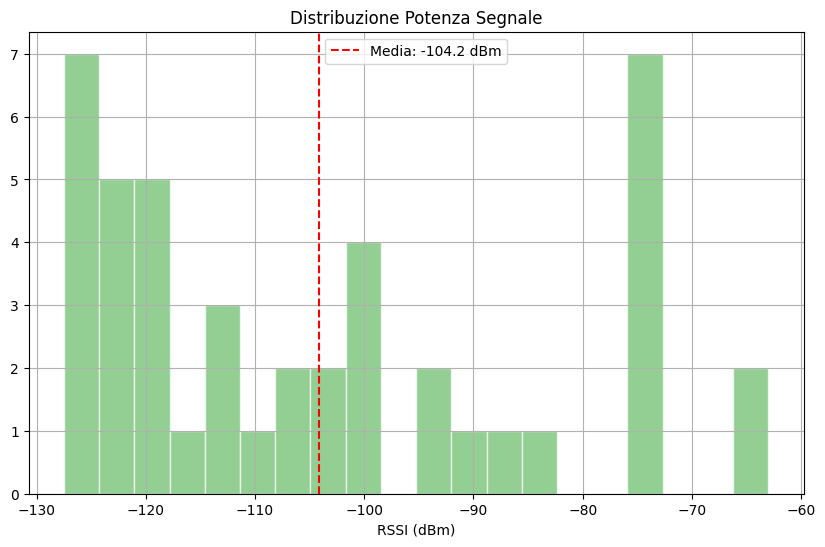

In [7]:
plt.figure(figsize=(10, 6))
df_phys['rssi'].hist(bins=20, color='#66BB66', alpha=0.7, edgecolor='white')
plt.axvline(df_phys['rssi'].mean(), color='red', linestyle='--', label=f"Media: {df_phys['rssi'].mean():.1f} dBm")
plt.title('Distribuzione Potenza Segnale')
plt.xlabel('RSSI (dBm)')
plt.legend()
plt.savefig(os.path.join(OUTPUT_FOLDER, '4_distribuzione_rssi.png'), dpi=300)
plt.show()